In [1]:
import pandas as pd
sheets = pd.read_excel("./data/Scats Data October 2006.xls", sheet_name=None)
sheets.keys()

dict_keys(['Notes', 'Data', 'Summary Of Data'])

What does the notes have to say?

In [2]:
sheets["Notes"]["Unnamed: 1"].dropna().to_list()

['Request: ',
 'Attached is the 24 hour volume for 40 SCATS sites collected in Boroondara Council',
 'Collection Period: 1st October 2006 to 31st October 2006 (1st October - last Sunday of School holidays)',
 'Data is available every 15minutes for each day collected. Data was validated as per ISD standards for all sites.',
 'On selected days the Data for the following sites was very poor and was removed: ',
 970,
 2000,
 2820,
 3001,
 3002,
 3127,
 3682,
 3685,
 4057,
 4262,
 4263,
 4264,
 4272,
 4812]

In [3]:
removed_days = sheets["Notes"]["Unnamed: 1"].dropna().to_list()[5:]
removed_days = [int(i) for i in removed_days]
removed_days

[970,
 2000,
 2820,
 3001,
 3002,
 3127,
 3682,
 3685,
 4057,
 4262,
 4263,
 4264,
 4272,
 4812]

In [4]:
df_info = sheets["Summary Of Data"].loc[2:]
df_info.columns = df_info.iloc[0]
df_info = df_info[1:]
df_info["SCATS Number"] = df_info["SCATS Number"].ffill()

df_info.dropna(axis=1, inplace=True)
df_info = df_info.convert_dtypes().infer_objects()
df_info.head(15)

2,SCATS Number,Location,Total
3,0970,HIGH STREET_RD E of WARRIGAL_RD,31
4,0970,HIGH STREET_RD W of WARRIGAL_RD,30
5,0970,WARRIGAL_RD N of HIGH STREET_RD,31
6,0970,WARRIGAL_RD S of HIGH STREET_RD,31
7,2000,BURWOOD_HWY E of WARRIGAL_RD,29
8,2000,TOORAK_RD W of WARRIGAL_RD,29
9,2000,WARRIGAL_RD N of TOORAK_RD,28
10,2000,WARRIGAL_RD S of BURWOOD_HWY,28
11,2200,MAROONDAH_HWY E of UNION_RD,31
12,2200,MAROONDAH_HWY W of UNION_RD,31


Threshold of Days

In [5]:
df_info_filtered = df_info[df_info["Total"].between(7, 31)]
df_info_filtered

2,SCATS Number,Location,Total
3,0970,HIGH STREET_RD E of WARRIGAL_RD,31
4,0970,HIGH STREET_RD W of WARRIGAL_RD,30
5,0970,WARRIGAL_RD N of HIGH STREET_RD,31
6,0970,WARRIGAL_RD S of HIGH STREET_RD,31
7,2000,BURWOOD_HWY E of WARRIGAL_RD,29
...,...,...,...
137,4812,SWAN_ST SW of MADDEN_GV,26
138,4821,BURNLEY_ST S OF VICTORIA_ST,31
139,4821,VICTORIA_ST E OF BURNLEY_ST,31
140,4821,VICTORIA_ST W OF BURNLEY_ST,31


so these are locations with actually reasonable values, so we can filter out the rest of the shitfuckery

In [6]:

# imagine having good formatting
df = sheets["Data"]
df.columns = pd.Series(df.loc[0])
df = df.loc[1:]

# remove added time
df.loc[:, 'Date'] = pd.to_datetime(df['Date']).dt.date
df = df.convert_dtypes()

# filter good locations
df = df.loc[df["Location"].isin(df_info_filtered["Location"])]

# add location identifier: SCARS Number + VicRoads Internal
df.loc[:, "Identifier"] = df["SCATS Number"].astype(str) + " - " + df["HF VicRoads Internal"].astype(str)
df.columns = df.columns.str.strip()


df.head(10)


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V87,V88,V89,V90,V91,V92,V93,V94,V95,Identifier
1,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-01,...,97,97,66,81,50,59,47,29,34,0970 - 249
2,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-02,...,102,107,114,80,60,62,48,44,26,0970 - 249
3,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-03,...,132,114,86,93,90,73,57,29,40,0970 - 249
4,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-04,...,113,132,101,113,90,78,66,52,44,0970 - 249
5,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-05,...,120,116,113,99,91,61,55,49,36,0970 - 249
6,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-06,...,137,135,136,108,120,115,102,74,78,0970 - 249
7,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-07,...,153,133,109,140,121,123,115,107,127,0970 - 249
8,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-08,...,92,96,82,80,64,64,48,48,43,0970 - 249
9,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-09,...,107,111,98,83,69,57,50,25,36,0970 - 249
10,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-10,...,131,124,111,112,103,66,50,49,36,0970 - 249


In [7]:
pd.Categorical(df["NB_TYPE_SURVEY"])

[1, 1, 1, 1, 1, ..., 1, 1, 1, 1, 1]
Length: 4128
Categories (1, Int64): [1]

In [8]:
test_unique_cols = ["SCATS Number","HF VicRoads Internal","VR Internal Stat","VR Internal Loc","Location"]

for col in test_unique_cols:
    print(pd.Categorical(df.groupby("Identifier")[col].nunique()))


[1, 1, 1, 1, 1, ..., 1, 1, 1, 1, 1]
Length: 137
Categories (1, int64): [1]
[1, 1, 1, 1, 1, ..., 1, 1, 1, 1, 1]
Length: 137
Categories (1, int64): [1]
[1, 1, 1, 1, 1, ..., 1, 1, 1, 1, 1]
Length: 137
Categories (1, int64): [1]
[1, 1, 1, 1, 1, ..., 1, 1, 1, 1, 1]
Length: 137
Categories (1, int64): [1]
[1, 1, 1, 1, 1, ..., 1, 1, 1, 1, 1]
Length: 137
Categories (1, int64): [1]


Using Identifiers to identify groups. Now, we need to drop irrelevant group info:

- SCATS Number, VicRoads Internal (included in identifier)
- Location (can be accessible via identifier later)
- Latitude and Longtitude (accessible via Location) (wait keeping this is better)
- VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY (what even are these?)

In [9]:
groups = df.groupby(by="Identifier")
for name, group in groups:
    # print("Name:", name)
    # print("Info:", group.info())
    gr = group.copy()
    gr = gr.drop(columns=["SCATS Number", "HF VicRoads Internal", "Location", "VR Internal Stat", "VR Internal Loc", "NB_TYPE_SURVEY", "CD_MELWAY"])
    gr.reset_index(drop=True, inplace=True)
    print(gr.head(5))
    gr.to_csv(f"data/boroondara/{name}.csv", index = False)
    print(f"Saved Group {name} to boroondara/{name}.csv")

0  NB_LATITUDE  NB_LONGITUDE        Date  V00  V01  V02  V03  V04  V05  V06  \
0     -37.8676     145.09146  2006-10-01   92   93   90   55   64   50   47   
1     -37.8676     145.09146  2006-10-02   31   19   20   20   12    8   12   
2     -37.8676     145.09146  2006-10-03   20   29   16    9    8   13    8   
3     -37.8676     145.09146  2006-10-04   32   30   26   13   22   17   13   
4     -37.8676     145.09146  2006-10-05   42   37   19   18   12   20   23   

0  ...  V87  V88  V89  V90  V91  V92  V93  V94  V95    Identifier  
0  ...  117   87   82   55   58   57   51   41   41  0970 - 10503  
1  ...  107  107   88   66   54   68   58   49   29  0970 - 10503  
2  ...  144  100  100  102   86   85   68   53   37  0970 - 10503  
3  ...  114  131   94   84   82   90   76   50   45  0970 - 10503  
4  ...  158  127  118   92  105  113   78   64   62  0970 - 10503  

[5 rows x 100 columns]
Saved Group 0970 - 10503 to boroondara/0970 - 10503.csv
0  NB_LATITUDE  NB_LONGITUDE        D

Now we transform to the type used by the *other* model

In [10]:
times_dict = {}
vcols = [f"V{str(i).zfill(2)}" for i in range(96)]
for col in vcols:
    i = int(col[1:]) if len(col[1:]) > 0 else 0
    t = i * 15 
    h = t // 60 
    m = t % 60
    times_dict[col] = f"{str(h).zfill(2)}:{str(m).zfill(2)}"
times_dict

{'V00': '00:00',
 'V01': '00:15',
 'V02': '00:30',
 'V03': '00:45',
 'V04': '01:00',
 'V05': '01:15',
 'V06': '01:30',
 'V07': '01:45',
 'V08': '02:00',
 'V09': '02:15',
 'V10': '02:30',
 'V11': '02:45',
 'V12': '03:00',
 'V13': '03:15',
 'V14': '03:30',
 'V15': '03:45',
 'V16': '04:00',
 'V17': '04:15',
 'V18': '04:30',
 'V19': '04:45',
 'V20': '05:00',
 'V21': '05:15',
 'V22': '05:30',
 'V23': '05:45',
 'V24': '06:00',
 'V25': '06:15',
 'V26': '06:30',
 'V27': '06:45',
 'V28': '07:00',
 'V29': '07:15',
 'V30': '07:30',
 'V31': '07:45',
 'V32': '08:00',
 'V33': '08:15',
 'V34': '08:30',
 'V35': '08:45',
 'V36': '09:00',
 'V37': '09:15',
 'V38': '09:30',
 'V39': '09:45',
 'V40': '10:00',
 'V41': '10:15',
 'V42': '10:30',
 'V43': '10:45',
 'V44': '11:00',
 'V45': '11:15',
 'V46': '11:30',
 'V47': '11:45',
 'V48': '12:00',
 'V49': '12:15',
 'V50': '12:30',
 'V51': '12:45',
 'V52': '13:00',
 'V53': '13:15',
 'V54': '13:30',
 'V55': '13:45',
 'V56': '14:00',
 'V57': '14:15',
 'V58': '14:30

In [11]:
df[vcols].to_numpy(dtype=int)

array([[ 86,  83,  52, ...,  47,  29,  34],
       [ 32,  28,  17, ...,  48,  44,  26],
       [ 26,  32,  21, ...,  57,  29,  40],
       ...,
       [100,  81,  89, ...,  60,  49,  45],
       [ 40,  29,  36, ...,  62,  50,  62],
       [ 36,  30,  24, ...,  63,  51,  54]], shape=(4128, 96))

In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
from typing import Any, Optional

def xiaochus_pipeline(identifier: str,
                      lags: int = 12,
                      train_ratio: float = 0.8,
                      seed: Optional[int] = None) -> Any:
#tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, MinMaxScaler]:
    df_id = pd.read_csv(f"data/boroondara/{identifier}.csv")
    flow = df_id[vcols].to_numpy(dtype=float).flatten()
    flow = np.array(np.nan_to_num(flow))
    cut = int(len(flow) * train_ratio)
    flow_train_raw = flow[:cut]
    flow_test_raw  = flow[cut:]
    
    scaler = MinMaxScaler(feature_range=(0, 1)).fit(flow_train_raw.reshape(-1, 1))

    flow_train = scaler.transform(flow_train_raw.reshape(-1, 1)).reshape(1, -1)[0]
    flow_test  = scaler.transform(flow_test_raw.reshape(-1, 1)).reshape(1, -1)[0]
    print(flow_train.shape)
    print(flow_test.shape)
    
    train_list, test_list = [], []
    for i in range(lags, len(flow_train)):
        train_list.append(flow_train[i - lags: i + 1])
    for i in range(lags, len(flow_test)):
        test_list.append(flow_test[i - lags: i + 1])
        
    train = np.array(train_list)
    test = np.array(test_list)
    print(f"Train:", train)
    print(f"Test:", test)
    print("Train shape:", train.shape)
    print("Test shape:", test.shape)
        
    if seed is not None:
        np.random.default_rng(seed)
        np.random.shuffle(train)
        
    X_train = train[:, :-1]
    y_train = train[:, -1]
    X_test = test[:, :-1]
    y_test = test[:, -1]
    print("Shape of X_train:", X_train.shape)
    print("Shape of X_test:", X_test.shape)
    print("Shape of y_train:", y_train.shape)
    print("Shape of y_test:", y_test.shape)
    
    return X_train, y_train, X_test, y_test, scaler


lag = 12    
X_train, X_test, y_train, y_test, scaler = xiaochus_pipeline("0970 - 249", lags=lag)
# print("Shape of X_train:", X_train.shape)
# print("Shape of X_test:", X_test.shape)
# print("Shape of y_train:", y_train.shape)
# print("Shape of y_test:", y_test.shape)
print(f"X_train = {X_train}")
print(f"y_train = {y_train}")
print(f"X_test = {X_test}")
print(f"y_test = {y_test}")
    

(2380,)
(596,)
Train: [[0.18930958 0.18262806 0.11358575 ... 0.03340757 0.05122494 0.05345212]
 [0.18262806 0.11358575 0.12694878 ... 0.05122494 0.05345212 0.05345212]
 [0.11358575 0.12694878 0.12917595 ... 0.05345212 0.05345212 0.0311804 ]
 ...
 [0.6481069  0.74387528 0.72160356 ... 0.78841871 0.73496659 0.6636971 ]
 [0.74387528 0.72160356 0.76391982 ... 0.73496659 0.6636971  0.60579065]
 [0.72160356 0.76391982 0.83296214 ... 0.6636971  0.60579065 0.53229399]]
Test: [[0.63697105 0.46547884 0.39198218 ... 0.27394209 0.28285078 0.29175947]
 [0.46547884 0.39198218 0.48552339 ... 0.28285078 0.29175947 0.28062361]
 [0.39198218 0.48552339 0.34521158 ... 0.29175947 0.28062361 0.19153675]
 ...
 [0.35857461 0.31625835 0.30734967 ... 0.17371938 0.155902   0.12026726]
 [0.31625835 0.30734967 0.3674833  ... 0.155902   0.12026726 0.09799555]
 [0.30734967 0.3674833  0.34521158 ... 0.12026726 0.09799555 0.07126949]]
Train shape: (2368, 13)
Test shape: (584, 13)
Shape of X_train: (2368, 12)
Shape of 

Loss Metric: MAPE

In [13]:
def MAPE(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean Absolute Percentage Error
    Calculate the mape.

    # Arguments
        y_true: List/ndarray, ture data.
        y_pred: List/ndarray, predicted data.
    # Returns
        mape: Double, result data for train.
    """

    y = [x for x in y_true if x > 0]
    y_pred = np.array([y_pred[i] for i in range(len(y_true)) if y_true[i] > 0])

    num: int = len(y_pred)
    sums: float = 0

    for i in range(num):
        tmp = abs(y[i] - y_pred[i]) / y[i]
        sums += tmp

    mape = sums * (100 / num)

    return mape

In [14]:
from model.model import get_cnn, get_gru, get_lstm, get_saes
from train import train_model, train_seas
from keras import Sequential



config: dict[str, Any] = {"batch": 256, "epochs": 600}

non_saes_layers = [lag, 64, 64, 1]
saes_layers = [lag, 400, 400, 400, 1]

models: dict[str, Sequential] = {
	"lstm": get_lstm(non_saes_layers), 
	"gru": get_gru(non_saes_layers),
	"cnn": get_cnn(non_saes_layers),
	"saes": get_saes(saes_layers)
}

def train_pipeline(identifier: str, model: str, lag: int = 12, config: dict[str, Any] = {"batch": 256, "epochs": 600}) -> None:
    X_train, y_train, _, _, _ = xiaochus_pipeline(identifier, lag)
    model = model.strip().lower()
    if model == "saes":
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
        m = models["saes"]
        train_seas(m, X_train, y_train, model, config)
    else:
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
        m = models[model]
        train_model(m, X_train, y_train, model, config)
    

identifier = "0970 - 249"

train_pipeline(identifier, "lstm", config={"batch": 256, "epochs": 10})


2025-11-13 08:21:27.687100: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-13 08:21:28.094525: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-13 08:21:30.612193: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


(2380,)
(596,)
Train: [[0.18930958 0.18262806 0.11358575 ... 0.03340757 0.05122494 0.05345212]
 [0.18262806 0.11358575 0.12694878 ... 0.05122494 0.05345212 0.05345212]
 [0.11358575 0.12694878 0.12917595 ... 0.05345212 0.05345212 0.0311804 ]
 ...
 [0.6481069  0.74387528 0.72160356 ... 0.78841871 0.73496659 0.6636971 ]
 [0.74387528 0.72160356 0.76391982 ... 0.73496659 0.6636971  0.60579065]
 [0.72160356 0.76391982 0.83296214 ... 0.6636971  0.60579065 0.53229399]]
Test: [[0.63697105 0.46547884 0.39198218 ... 0.27394209 0.28285078 0.29175947]
 [0.46547884 0.39198218 0.48552339 ... 0.28285078 0.29175947 0.28062361]
 [0.39198218 0.48552339 0.34521158 ... 0.29175947 0.28062361 0.19153675]
 ...
 [0.35857461 0.31625835 0.30734967 ... 0.17371938 0.155902   0.12026726]
 [0.31625835 0.30734967 0.3674833  ... 0.155902   0.12026726 0.09799555]
 [0.30734967 0.3674833  0.34521158 ... 0.12026726 0.09799555 0.07126949]]
Train shape: (2368, 13)
Test shape: (584, 13)
Shape of X_train: (2368, 12)
Shape of 

(2380,)
(596,)
Train: [[0.18930958 0.18262806 0.11358575 ... 0.03340757 0.05122494 0.05345212]
 [0.18262806 0.11358575 0.12694878 ... 0.05122494 0.05345212 0.05345212]
 [0.11358575 0.12694878 0.12917595 ... 0.05345212 0.05345212 0.0311804 ]
 ...
 [0.6481069  0.74387528 0.72160356 ... 0.78841871 0.73496659 0.6636971 ]
 [0.74387528 0.72160356 0.76391982 ... 0.73496659 0.6636971  0.60579065]
 [0.72160356 0.76391982 0.83296214 ... 0.6636971  0.60579065 0.53229399]]
Test: [[0.63697105 0.46547884 0.39198218 ... 0.27394209 0.28285078 0.29175947]
 [0.46547884 0.39198218 0.48552339 ... 0.28285078 0.29175947 0.28062361]
 [0.39198218 0.48552339 0.34521158 ... 0.29175947 0.28062361 0.19153675]
 ...
 [0.35857461 0.31625835 0.30734967 ... 0.17371938 0.155902   0.12026726]
 [0.31625835 0.30734967 0.3674833  ... 0.155902   0.12026726 0.09799555]
 [0.30734967 0.3674833  0.34521158 ... 0.12026726 0.09799555 0.07126949]]
Train shape: (2368, 13)
Test shape: (584, 13)
Shape of X_train: (2368, 12)
Shape of 

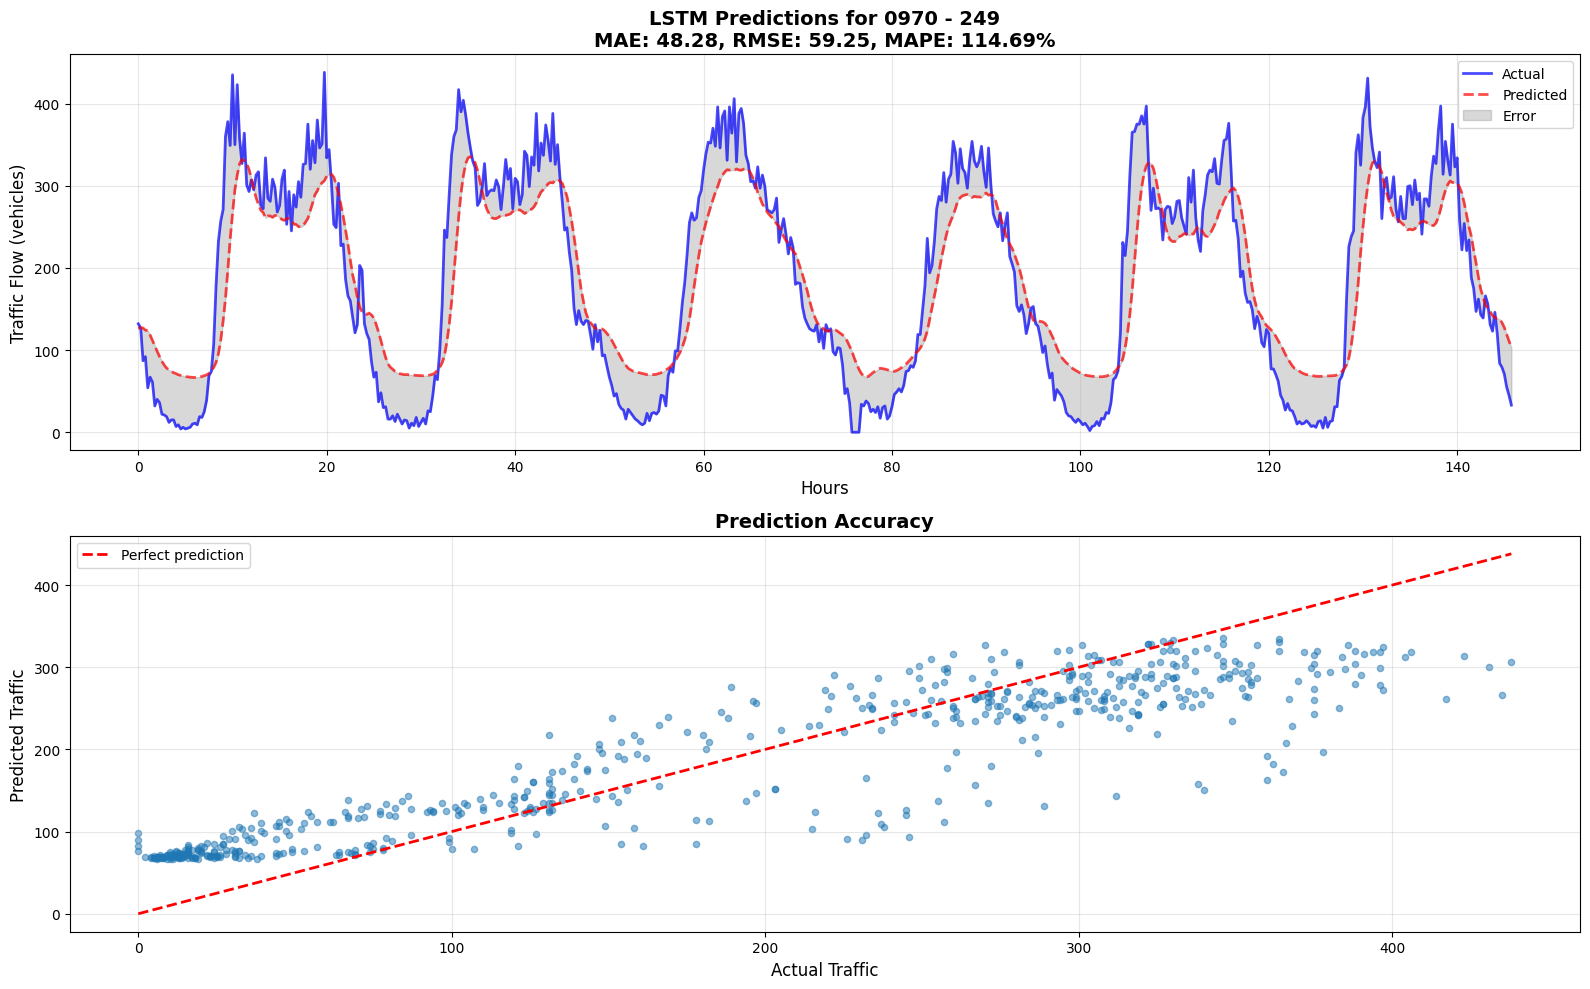


EVALUATION: LSTM on 0970 - 249
MAE:  48.28 vehicles
RMSE: 59.25 vehicles
MAPE: 114.69%
Mean traffic: 188.39 vehicles
Prediction variance: 8259.87
Actual variance: 16725.72



(np.float64(48.27836330622843),
 np.float64(59.24906726238428),
 np.float64(114.68878188348725))

In [16]:
def plot_identifier(identifier: str, model_name: str = 'lstm', days_to_plot: int = 3):
    """
    Visualize model predictions vs actual traffic for a specific location.
    
    Args:
        identifier: Location identifier (e.g., "0970 - 249")
        model_name: Model type ('lstm', 'gru', 'cnn', 'saes')
        days_to_plot: Number of days to visualize
    """
    import matplotlib.pyplot as plt
    from keras.saving import load_model
    
    # Load data
    X_train, y_train, X_test, y_test, scaler = xiaochus_pipeline(identifier, lags=12)
    
    # Load trained model
    try:
        model = load_model(f'model/{model_name}.keras')
    except:
        print(f"Model {model_name}.keras not found. Train it first!")
        return
    
    # Reshape for prediction
    X_test_reshaped = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Predict (normalized)
    y_pred_norm = model.predict(X_test_reshaped, verbose=0).flatten()
    
    # Denormalize to original scale
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_actual = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
    
    # Calculate metrics
    mae = np.mean(np.abs(y_test_actual - y_pred_actual))
    rmse = np.sqrt(np.mean((y_test_actual - y_pred_actual) ** 2))
    mape = MAPE(y_test_actual, y_pred_actual)
    
    # Plot
    samples = min(days_to_plot * 96, len(y_test_actual))  # 96 intervals per day
    hours = np.arange(samples) * 0.25
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # Time series plot
    axes[0].plot(hours, y_test_actual[:samples], 'b-', label='Actual', linewidth=2, alpha=0.7)
    axes[0].plot(hours, y_pred_actual[:samples], 'r--', label='Predicted', linewidth=2, alpha=0.7)
    axes[0].fill_between(hours, y_test_actual[:samples], y_pred_actual[:samples], 
                         alpha=0.3, color='gray', label='Error')
    axes[0].set_xlabel('Hours', fontsize=12)
    axes[0].set_ylabel('Traffic Flow (vehicles)', fontsize=12)
    axes[0].set_title(f'{model_name.upper()} Predictions for {identifier}\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%', 
                     fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Scatter plot
    axes[1].scatter(y_test_actual[:samples], y_pred_actual[:samples], alpha=0.5, s=20)
    axes[1].plot([y_test_actual[:samples].min(), y_test_actual[:samples].max()],
                 [y_test_actual[:samples].min(), y_test_actual[:samples].max()],
                 'r--', lw=2, label='Perfect prediction')
    axes[1].set_xlabel('Actual Traffic', fontsize=12)
    axes[1].set_ylabel('Predicted Traffic', fontsize=12)
    axes[1].set_title('Prediction Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'single_location/{identifier.replace(" ", "_")}_{model_name}_prediction.png', dpi=300)
    plt.show()
    
    # Print detailed stats
    print(f"\n{'='*60}")
    print(f"EVALUATION: {model_name.upper()} on {identifier}")
    print(f"{'='*60}")
    print(f"MAE:  {mae:.2f} vehicles")
    print(f"RMSE: {rmse:.2f} vehicles")
    print(f"MAPE: {mape:.2f}%")
    print(f"Mean traffic: {y_test_actual.mean():.2f} vehicles")
    print(f"Prediction variance: {y_pred_actual.var():.2f}")
    print(f"Actual variance: {y_test_actual.var():.2f}")
    print(f"{'='*60}\n")
    
    return mae, rmse, mape


# Test it
plot_identifier("0970 - 249", model_name='lstm', days_to_plot=7)

Found 137 locations

🎯 OPTION 1: Train LSTM for all locations

TRAINING LSTM FOR 137 LOCATIONS
Configuration: lag=12, batch=256, epochs=10


[1/137] Processing: 0970 - 10503
------------------------------------------------------------
(2380,)
(596,)
Train: [[0.19189765 0.19402985 0.18763326 ... 0.06823028 0.04690832 0.06823028]
 [0.19402985 0.18763326 0.1130064  ... 0.04690832 0.06823028 0.0554371 ]
 [0.18763326 0.1130064  0.13219616 ... 0.06823028 0.0554371  0.03624733]
 ...
 [0.76972281 0.73560768 0.76332623 ... 0.74626866 0.75053305 0.71428571]
 [0.73560768 0.76332623 0.73773987 ... 0.75053305 0.71428571 0.84434968]
 [0.76332623 0.73773987 0.91044776 ... 0.71428571 0.84434968 0.66950959]]
Test: [[0.56716418 0.46908316 0.39445629 ... 0.30490405 0.27078891 0.23027719]
 [0.46908316 0.39445629 0.14925373 ... 0.27078891 0.23027719 0.24093817]
 [0.39445629 0.14925373 0.3326226  ... 0.23027719 0.24093817 0.20895522]
 ...
 [0.36886994 0.32196162 0.29637527 ... 0.20469083 0.18336887 0.110874

KeyError: 'status'

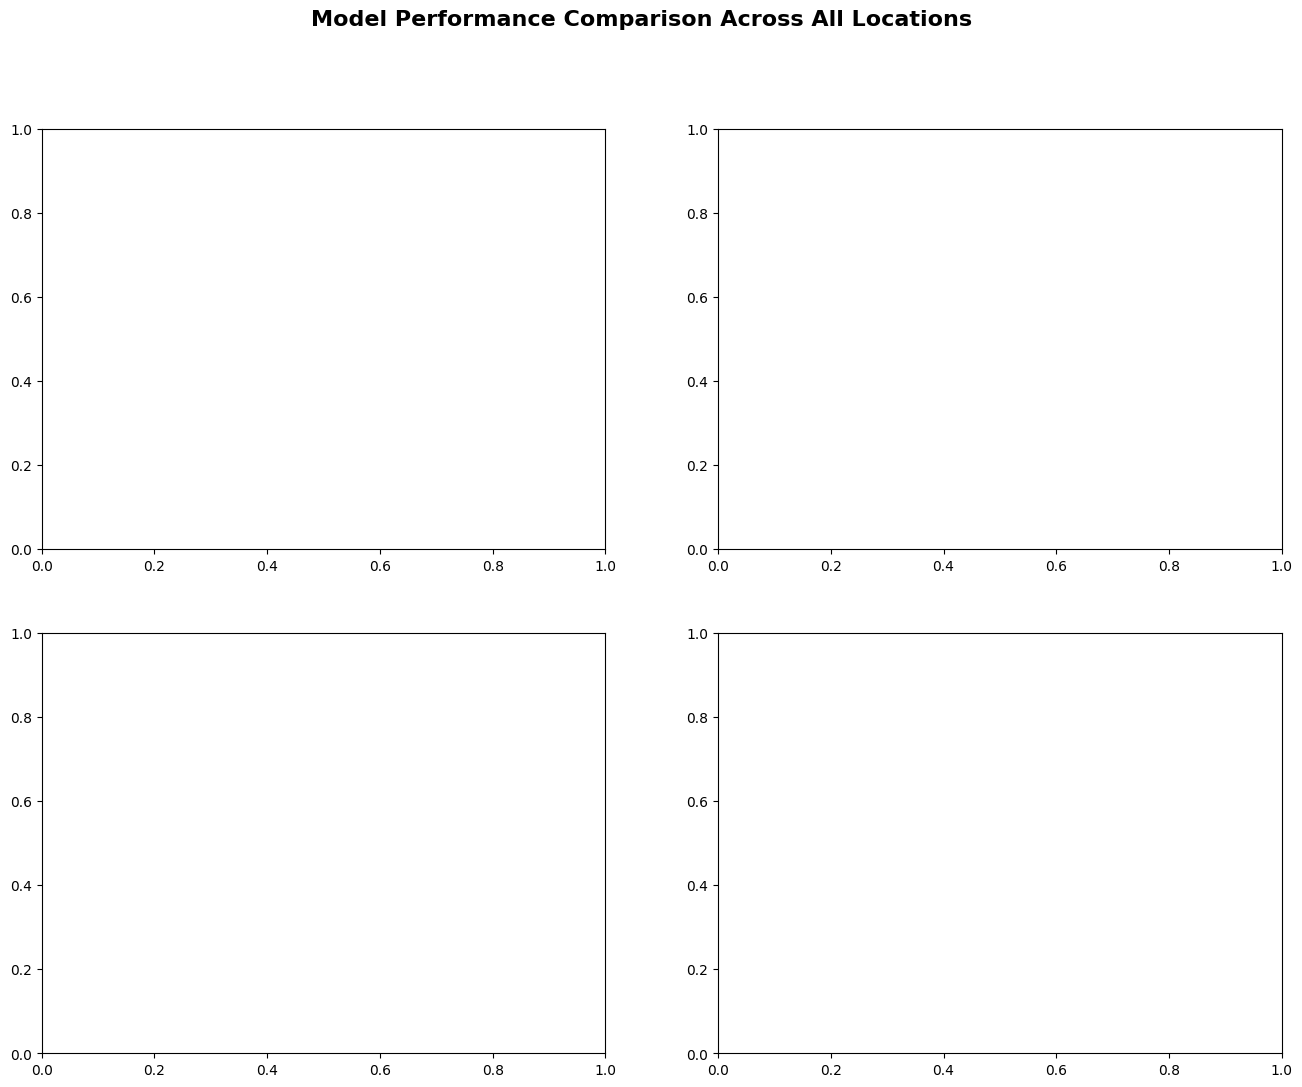

In [18]:
# ====================================
# MASS TRAINING: ALL LOCATIONS
# ====================================
import os
from pathlib import Path
import time
from glob import glob
import matplotlib.pyplot as plt

# Get all location identifiers
location_files = glob("data/boroondara/*.csv")
all_identifiers = [Path(f).stem for f in location_files]
print(f"Found {len(all_identifiers)} locations")

def train_all_locations(model_name: str = 'lstm', 
                       lag: int = 12,
                       config: dict[str, Any] = {"batch": 256, "epochs": 50},
                       max_locations: int = None):
    """
    Train a model for all locations individually.
    
    Args:
        model_name: Model type ('lstm', 'gru', 'cnn', 'saes')
        lag: Number of lag timesteps
        config: Training configuration
        max_locations: Limit number of locations (None = all)
    
    Returns:
        Dictionary with training results
    """
    # Limit locations if specified
    identifiers_to_train = all_identifiers[:max_locations] if max_locations else all_identifiers
    
    print(f"\n{'='*70}")
    print(f"TRAINING {model_name.upper()} FOR {len(identifiers_to_train)} LOCATIONS")
    print(f"{'='*70}")
    print(f"Configuration: lag={lag}, batch={config['batch']}, epochs={config['epochs']}")
    print(f"{'='*70}\n")
    
    results = {
        'identifier': [],
        'model': [],
        'mae': [],
        'rmse': [],
        'mape': [],
        'mean_traffic': [],
        'training_time': [],
        'status': []
    }
    
    # Create output directory
    Path(f'model/individual/{model_name}').mkdir(parents=True, exist_ok=True)
    
    start_time = time.time()
    
    for idx, identifier in enumerate(identifiers_to_train, 1):
        print(f"\n[{idx}/{len(identifiers_to_train)}] Processing: {identifier}")
        print("-" * 60)
        
        loc_start_time = time.time()
        
        try:
            # Load data
            X_train, y_train, X_test, y_test, scaler = xiaochus_pipeline(identifier, lags=lag)
            
            # Check data quality
            if len(X_train) < 50:
                print(f"⚠️  Skipping {identifier}: Insufficient data ({len(X_train)} samples)")
                results['identifier'].append(identifier)
                results['model'].append(model_name)
                results['mae'].append(None)
                results['rmse'].append(None)
                results['mape'].append(None)
                results['mean_traffic'].append(None)
                results['training_time'].append(0)
                results['status'].append('insufficient_data')
                continue
            
            # Reshape for training
            X_train_reshaped = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
            X_test_reshaped = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
            
            # Get model
            non_saes_layers = [lag, 64, 64, 1]
            saes_layers = [lag, 400, 400, 400, 1]
            
            if model_name == 'saes':
                model = get_saes(saes_layers)
            elif model_name == 'lstm':
                model = get_lstm(non_saes_layers)
            elif model_name == 'gru':
                model = get_gru(non_saes_layers)
            elif model_name == 'cnn':
                model = get_cnn(non_saes_layers)
            
            # Train
            model.compile(loss='mse', optimizer='adam')
            
            history = model.fit(
                X_train_reshaped, y_train,
                validation_split=0.2,
                epochs=config['epochs'],
                batch_size=config['batch'],
                verbose=0  # Silent training
            )
            
            # Save model
            safe_name = identifier.replace(" ", "_").replace("-", "_")
            model_path = f'model/individual/{model_name}/{safe_name}.keras'
            model.save(model_path)
            
            # Evaluate
            y_pred_norm = model.predict(X_test_reshaped, verbose=0).flatten()
            y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
            y_pred_actual = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
            
            mae = np.mean(np.abs(y_test_actual - y_pred_actual))
            rmse = np.sqrt(np.mean((y_test_actual - y_pred_actual) ** 2))
            mape = MAPE(y_test_actual, y_pred_actual)
            mean_traffic = y_test_actual.mean()
            
            training_time = time.time() - loc_start_time
            
            # Store results
            results['identifier'].append(identifier)
            results['model'].append(model_name)
            results['mae'].append(mae)
            results['rmse'].append(rmse)
            results['mape'].append(mape)
            results['mean_traffic'].append(mean_traffic)
            results['training_time'].append(training_time)
            results['status'].append('success')
            
            print(f"✓ MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.1f}% ({training_time:.1f}s)")
            
        except Exception as e:
            print(f"✗ FAILED: {str(e)}")
            results['identifier'].append(identifier)
            results['model'].append(model_name)
            results['mae'].append(None)
            results['rmse'].append(None)
            results['mape'].append(None)
            results['mean_traffic'].append(None)
            results['training_time'].append(time.time() - loc_start_time)
            results['status'].append('error')
            continue
    
    total_time = time.time() - start_time
    
    # Summary
    results_df = pd.DataFrame(results)
    successful = results_df[results_df['status'] == 'success']
    
    print(f"\n{'='*70}")
    print(f"TRAINING SUMMARY: {model_name.upper()}")
    print(f"{'='*70}")
    print(f"Total locations: {len(identifiers_to_train)}")
    print(f"Successful: {len(successful)}")
    print(f"Failed: {len(results_df) - len(successful)}")
    print(f"Total time: {total_time/60:.1f} minutes")
    
    if len(successful) > 0:
        print(f"\n📊 Performance Statistics:")
        print(f"  Average MAE:  {successful['mae'].mean():.2f} ± {successful['mae'].std():.2f}")
        print(f"  Average RMSE: {successful['rmse'].mean():.2f} ± {successful['rmse'].std():.2f}")
        print(f"  Average MAPE: {successful['mape'].mean():.1f}% ± {successful['mape'].std():.1f}%")
        print(f"  Median MAPE:  {successful['mape'].median():.1f}%")
        print(f"  Best MAPE:    {successful['mape'].min():.1f}% ({successful.loc[successful['mape'].idxmin(), 'identifier']})")
        print(f"  Worst MAPE:   {successful['mape'].max():.1f}% ({successful.loc[successful['mape'].idxmax(), 'identifier']})")
    
    print(f"{'='*70}\n")
    
    # Save results
    results_df.to_csv(f'model/individual/{model_name}_results.csv', index=False)
    print(f"✓ Results saved to model/individual/{model_name}_results.csv")
    
    return results_df


# ====================================
# TRAIN ALL MODELS FOR ALL LOCATIONS
# ====================================
def train_all_models_all_locations(models_to_train: list[str] = ['lstm', 'gru', 'cnn'],
                                   lag: int = 12,
                                   config: dict[str, Any] = {"batch": 256, "epochs": 50},
                                   max_locations: int = None):
    """
    Train multiple models for all locations.
    
    Args:
        models_to_train: List of model names
        lag: Number of lag timesteps
        config: Training configuration
        max_locations: Limit number of locations
    
    Returns:
        Dictionary of results DataFrames
    """
    all_results = {}
    
    print(f"\n🚀 MASS TRAINING PIPELINE")
    print(f"Models: {', '.join([m.upper() for m in models_to_train])}")
    print(f"Locations: {max_locations if max_locations else 'All'}")
    print(f"Configuration: {config}")
    
    for model_name in models_to_train:
        results_df = train_all_locations(model_name, lag, config, max_locations)
        all_results[model_name] = results_df
    
    # Combined analysis
    print(f"\n{'='*70}")
    print(f"COMBINED RESULTS")
    print(f"{'='*70}")
    
    for model_name, results_df in all_results.items():
        successful = results_df[results_df['status'] == 'success']
        if len(successful) > 0:
            print(f"{model_name.upper():6s}: Median MAPE = {successful['mape'].median():.1f}%, Success rate = {len(successful)/len(results_df)*100:.0f}%")
    
    return all_results


# ====================================
# VISUALIZE RESULTS
# ====================================
def visualize_training_results(results_dict: dict):
    """Create visualizations comparing model performance."""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Model Performance Comparison Across All Locations', fontsize=16, fontweight='bold')
    
    # Prepare data
    models = list(results_dict.keys())
    colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
    
    # 1. MAPE Distribution
    ax = axes[0, 0]
    mape_data = []
    labels = []
    for model_name, results_df in results_dict.items():
        successful = results_df[results_df['status'] == 'success']
        if len(successful) > 0:
            mape_data.append(successful['mape'].dropna().values)
            labels.append(model_name.upper())
    
    bp = ax.boxplot(mape_data, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_ylabel('MAPE (%)', fontsize=11)
    ax.set_title('MAPE Distribution', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. MAE Comparison
    ax = axes[0, 1]
    mae_means = []
    mae_stds = []
    for model_name in models:
        successful = results_dict[model_name][results_dict[model_name]['status'] == 'success']
        mae_means.append(successful['mae'].mean())
        mae_stds.append(successful['mae'].std())
    
    x_pos = np.arange(len(models))
    ax.bar(x_pos, mae_means, yerr=mae_stds, color=colors[:len(models)], alpha=0.7, capsize=5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([m.upper() for m in models])
    ax.set_ylabel('MAE (vehicles)', fontsize=11)
    ax.set_title('Mean Absolute Error', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 3. Success Rate
    ax = axes[1, 0]
    success_rates = []
    for model_name in models:
        results_df = results_dict[model_name]
        success_rate = len(results_df[results_df['status'] == 'success']) / len(results_df) * 100
        success_rates.append(success_rate)
    
    ax.bar(x_pos, success_rates, color=colors[:len(models)], alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([m.upper() for m in models])
    ax.set_ylabel('Success Rate (%)', fontsize=11)
    ax.set_title('Training Success Rate', fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels
    for i, v in enumerate(success_rates):
        ax.text(i, v + 2, f'{v:.0f}%', ha='center', fontweight='bold')
    
    # 4. Training Time
    ax = axes[1, 1]
    time_data = []
    for model_name in models:
        successful = results_dict[model_name][results_dict[model_name]['status'] == 'success']
        time_data.append(successful['training_time'].sum() / 60)  # Convert to minutes
    
    ax.bar(x_pos, time_data, color=colors[:len(models)], alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([m.upper() for m in models])
    ax.set_ylabel('Total Training Time (minutes)', fontsize=11)
    ax.set_title('Computational Cost', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('model/individual/comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved comparison plot to model/individual/comparison.png")


# ====================================
# EXAMPLE USAGE
# ====================================

# Option 1: Train one model for all locations
print("\n🎯 OPTION 1: Train LSTM for all locations")
lstm_results = train_all_locations('lstm', lag=12, config={"batch": 256, "epochs": 10})
print(lstm_results)

# # Option 2: Train one model for limited locations (testing)
# print("\n🎯 OPTION 2: Train LSTM for first 10 locations (quick test)")
# lstm_results_test = train_all_locations('lstm', lag=12, config={"batch": 128, "epochs": 20}, max_locations=10)

# # Option 3: Train all models for all locations (FULL RUN)
# print("\n🎯 OPTION 3: Train all models for all locations")
# all_results = train_all_models_all_locations(
#     models_to_train=['lstm', 'gru', 'cnn'],
#     lag=12,
#     config={"batch": 256, "epochs": 50}
# )

# Visualize results
visualize_training_results(lstm_results.to_dict())

# ====================================
# LOAD AND COMPARE EXISTING RESULTS
# ====================================
def load_and_compare_results():
    """Load previously saved results and compare."""
    result_files = glob("model/individual/*_results.csv")
    
    if not result_files:
        print("No previous results found!")
        return
    
    results_dict = {}
    for file in result_files:
        model_name = Path(file).stem.replace('_results', '')
        results_dict[model_name] = pd.read_csv(file)
    
    visualize_training_results(results_dict)
    
    return results_dict

# Load previous results if they exist
# previous_results = load_and_compare_results()

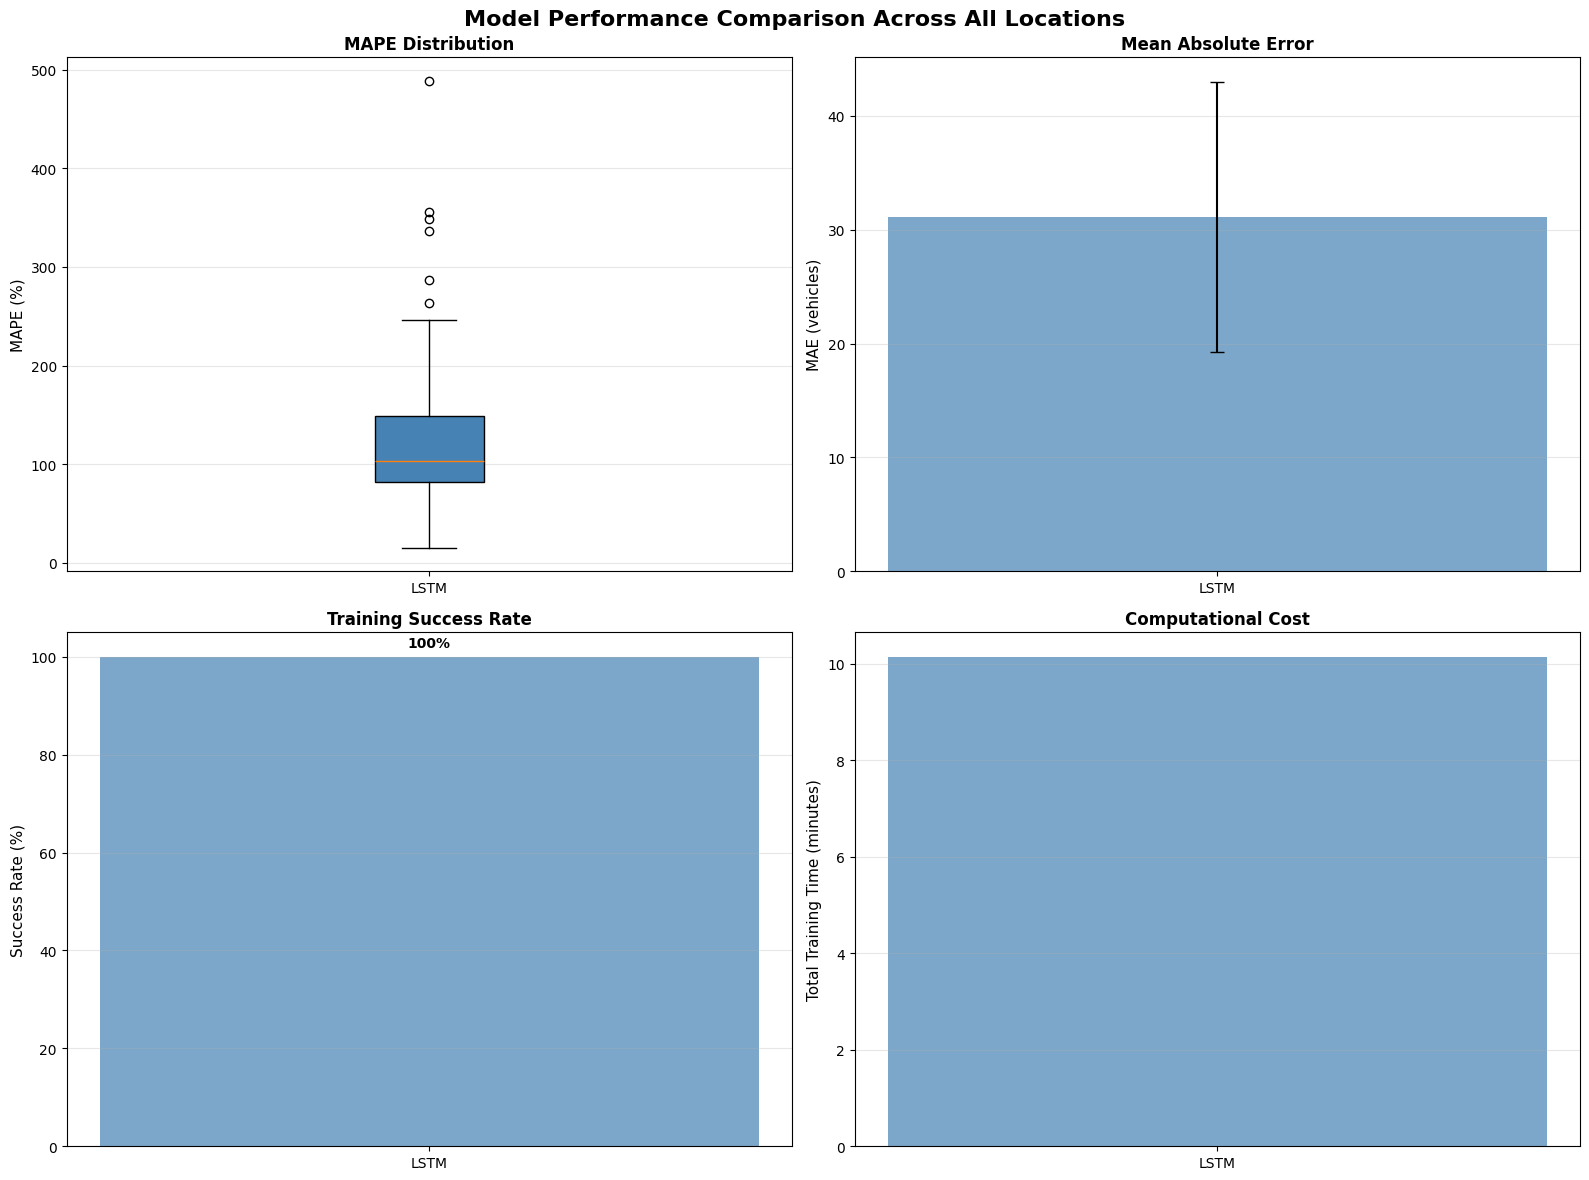

✓ Saved comparison plot to model/individual/comparison.png


In [19]:
visualize_training_results({'lstm': lstm_results})  # ← CORRECT WAY


🎯 OPTION 1: Single location prediction
(2380,)
(596,)
Train: [[0.18930958 0.18262806 0.11358575 ... 0.03340757 0.05122494 0.05345212]
 [0.18262806 0.11358575 0.12694878 ... 0.05122494 0.05345212 0.05345212]
 [0.11358575 0.12694878 0.12917595 ... 0.05345212 0.05345212 0.0311804 ]
 ...
 [0.6481069  0.74387528 0.72160356 ... 0.78841871 0.73496659 0.6636971 ]
 [0.74387528 0.72160356 0.76391982 ... 0.73496659 0.6636971  0.60579065]
 [0.72160356 0.76391982 0.83296214 ... 0.6636971  0.60579065 0.53229399]]
Test: [[0.63697105 0.46547884 0.39198218 ... 0.27394209 0.28285078 0.29175947]
 [0.46547884 0.39198218 0.48552339 ... 0.28285078 0.29175947 0.28062361]
 [0.39198218 0.48552339 0.34521158 ... 0.29175947 0.28062361 0.19153675]
 ...
 [0.35857461 0.31625835 0.30734967 ... 0.17371938 0.155902   0.12026726]
 [0.31625835 0.30734967 0.3674833  ... 0.155902   0.12026726 0.09799555]
 [0.30734967 0.3674833  0.34521158 ... 0.12026726 0.09799555 0.07126949]]
Train shape: (2368, 13)
Test shape: (584, 13

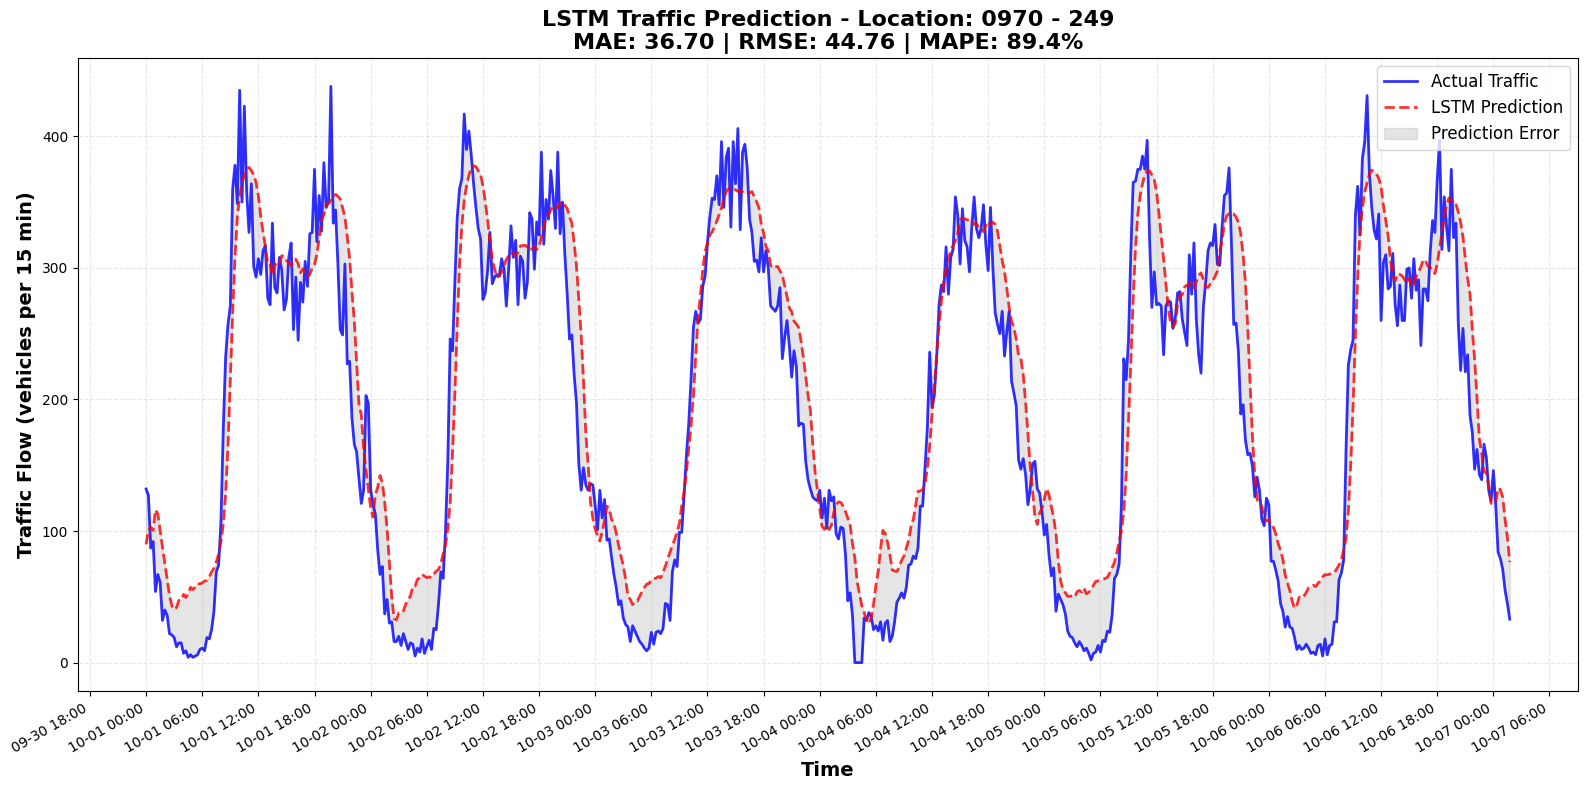

(np.float64(36.70177591663517),
 np.float64(44.75919974176491),
 np.float64(89.42221856620301))

In [20]:
# ====================================
# PREDICTION VISUALIZATION FOR ALL LOCATIONS
# ====================================
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateFormatter
import matplotlib.dates as mdates
from datetime import datetime, timedelta

def predict_and_plot_identifier(identifier: str, 
                                model_name: str = 'lstm', 
                                days_to_plot: int = 3,
                                save_plot: bool = True):
    """
    Generate prediction graph for a single location (similar to main.py).
    
    Args:
        identifier: Location identifier (e.g., "0970 - 249")
        model_name: Model type ('lstm', 'gru', 'cnn', 'saes')
        days_to_plot: Number of days to visualize
        save_plot: Whether to save the plot to file
    
    Returns:
        mae, rmse, mape metrics
    """
    from keras.saving import load_model
    
    # Load data
    X_train, y_train, X_test, y_test, scaler = xiaochus_pipeline(identifier, lags=12)
    
    # Load trained model
    safe_name = identifier.replace(" ", "_").replace("-", "_")
    model_path = f'model/individual/{model_name}/{safe_name}.keras'
    
    try:
        model = load_model(model_path)
    except:
        print(f"⚠️  Model not found: {model_path}")
        print(f"Train the model first using train_all_locations('{model_name}')")
        return None, None, None
    
    # Reshape for prediction
    if model_name == 'saes':
        X_test_reshaped = np.reshape(X_test, (X_test.shape[0], X_test.shape[1]))
    else:
        X_test_reshaped = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Predict (normalized)
    y_pred_norm = model.predict(X_test_reshaped, verbose=0).flatten()
    
    # Denormalize to original scale
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_actual = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
    
    # Calculate metrics
    mae = np.mean(np.abs(y_test_actual - y_pred_actual))
    rmse = np.sqrt(np.mean((y_test_actual - y_pred_actual) ** 2))
    mape = MAPE(y_test_actual, y_pred_actual)
    
    # Limit to specified days
    samples = min(days_to_plot * 96, len(y_test_actual))  # 96 intervals per day (15-min each)
    y_test_plot = y_test_actual[:samples]
    y_pred_plot = y_pred_actual[:samples]
    
    # Create time axis (similar to main.py)
    # Assume data starts at midnight
    start_time = datetime(2006, 10, 1, 0, 0)  # Adjust as needed
    time_points = [start_time + timedelta(minutes=15*i) for i in range(samples)]
    
    # Create figure (similar to main.py style)
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Plot actual vs predicted
    ax.plot(time_points, y_test_plot, 'b-', label='Actual Traffic', linewidth=2, alpha=0.8)
    ax.plot(time_points, y_pred_plot, 'r--', label=f'{model_name.upper()} Prediction', linewidth=2, alpha=0.8)
    
    # Fill between for error visualization
    ax.fill_between(time_points, y_test_plot, y_pred_plot, 
                    alpha=0.2, color='gray', label='Prediction Error')
    
    # Formatting (similar to main.py)
    ax.set_xlabel('Time', fontsize=14, fontweight='bold')
    ax.set_ylabel('Traffic Flow (vehicles per 15 min)', fontsize=14, fontweight='bold')
    ax.set_title(f'{model_name.upper()} Traffic Prediction - Location: {identifier}\n'
                f'MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.1f}%',
                fontsize=16, fontweight='bold')
    
    # Format x-axis to show time
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))  # Show every 6 hours
    fig.autofmt_xdate()  # Rotate date labels
    
    # Grid and legend
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=12)
    
    plt.tight_layout()
    
    # Save plot
    if save_plot:
        save_dir = Path(f'predictions/{model_name}')
        save_dir.mkdir(parents=True, exist_ok=True)
        safe_filename = identifier.replace(" ", "_").replace("-", "_")
        save_path = save_dir / f'{safe_filename}_prediction.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    
    return mae, rmse, mape


def predict_all_locations(model_name: str = 'lstm',
                         days_to_plot: int = 3,
                         max_locations: int = None,
                         save_plots: bool = True):
    """
    Generate prediction graphs for all locations.
    
    Args:
        model_name: Model type ('lstm', 'gru', 'cnn', 'saes')
        days_to_plot: Number of days to visualize per location
        max_locations: Limit number of locations (None = all)
        save_plots: Whether to save plots to files
    
    Returns:
        DataFrame with prediction metrics for all locations
    """
    identifiers_to_plot = all_identifiers[:max_locations] if max_locations else all_identifiers
    
    print(f"\n{'='*70}")
    print(f"GENERATING PREDICTIONS FOR {len(identifiers_to_plot)} LOCATIONS")
    print(f"Model: {model_name.upper()}")
    print(f"{'='*70}\n")
    
    results = {
        'identifier': [],
        'mae': [],
        'rmse': [],
        'mape': []
    }
    
    for idx, identifier in enumerate(identifiers_to_plot, 1):
        print(f"\n[{idx}/{len(identifiers_to_plot)}] Processing: {identifier}")
        print("-" * 60)
        
        try:
            mae, rmse, mape = predict_and_plot_identifier(
                identifier, 
                model_name, 
                days_to_plot, 
                save_plots
            )
            
            if mae is not None:
                results['identifier'].append(identifier)
                results['mae'].append(mae)
                results['rmse'].append(rmse)
                results['mape'].append(mape)
                print(f"✓ MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.1f}%")
            
        except Exception as e:
            print(f"✗ Failed: {str(e)}")
            continue
    
    results_df = pd.DataFrame(results)
    
    # Summary
    print(f"\n{'='*70}")
    print(f"PREDICTION SUMMARY")
    print(f"{'='*70}")
    print(f"Total locations: {len(identifiers_to_plot)}")
    print(f"Successful: {len(results_df)}")
    print(f"\n📊 Prediction Accuracy:")
    print(f"  Average MAE:  {results_df['mae'].mean():.2f} vehicles")
    print(f"  Average RMSE: {results_df['rmse'].mean():.2f} vehicles")
    print(f"  Average MAPE: {results_df['mape'].mean():.1f}%")
    print(f"  Median MAPE:  {results_df['mape'].median():.1f}%")
    print(f"{'='*70}\n")
    
    # Save results
    save_path = f'predictions/{model_name}_prediction_results.csv'
    results_df.to_csv(save_path, index=False)
    print(f"✓ Results saved to {save_path}")
    
    return results_df


def compare_models_for_location(identifier: str, 
                                models: list[str] = ['lstm', 'gru', 'cnn'],
                                days_to_plot: int = 3):
    """
    Compare multiple models for a single location (similar to main.py multi-model comparison).
    
    Args:
        identifier: Location identifier
        models: List of model names to compare
        days_to_plot: Number of days to visualize
    """
    from keras.saving import load_model
    
    # Load data once
    X_train, y_train, X_test, y_test, scaler = xiaochus_pipeline(identifier, lags=12)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # Limit to specified days
    samples = min(days_to_plot * 96, len(y_test_actual))
    y_test_plot = y_test_actual[:samples]
    
    # Create time axis
    start_time = datetime(2006, 10, 1, 0, 0)
    time_points = [start_time + timedelta(minutes=15*i) for i in range(samples)]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Plot actual data
    ax.plot(time_points, y_test_plot, 'b-', label='Actual Traffic', 
            linewidth=3, alpha=0.8, zorder=10)
    
    # Colors for different models
    colors = {'lstm': 'red', 'gru': 'green', 'cnn': 'orange', 'saes': 'purple'}
    styles = {'lstm': '--', 'gru': '-.', 'cnn': ':', 'saes': '--'}
    
    metrics = {}
    
    # Plot predictions for each model
    for model_name in models:
        try:
            safe_name = identifier.replace(" ", "_").replace("-", "_")
            model_path = f'model/individual/{model_name}/{safe_name}.keras'
            model = load_model(model_path)
            
            # Predict
            if model_name == 'saes':
                X_test_reshaped = np.reshape(X_test, (X_test.shape[0], X_test.shape[1]))
            else:
                X_test_reshaped = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
            
            y_pred_norm = model.predict(X_test_reshaped, verbose=0).flatten()
            y_pred_actual = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
            y_pred_plot = y_pred_actual[:samples]
            
            # Calculate metrics
            mae = np.mean(np.abs(y_test_plot - y_pred_plot))
            mape = MAPE(y_test_plot, y_pred_plot)
            metrics[model_name] = {'mae': mae, 'mape': mape}
            
            # Plot
            ax.plot(time_points, y_pred_plot, 
                   color=colors.get(model_name, 'gray'),
                   linestyle=styles.get(model_name, '-'),
                   label=f'{model_name.upper()} (MAPE: {mape:.1f}%)',
                   linewidth=2, alpha=0.7)
            
        except Exception as e:
            print(f"⚠️  Could not load {model_name}: {e}")
            continue
    
    # Formatting
    ax.set_xlabel('Time', fontsize=14, fontweight='bold')
    ax.set_ylabel('Traffic Flow (vehicles per 15 min)', fontsize=14, fontweight='bold')
    ax.set_title(f'Model Comparison - Location: {identifier}',
                fontsize=16, fontweight='bold')
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    fig.autofmt_xdate()
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=11)
    
    plt.tight_layout()
    
    # Save
    save_dir = Path('predictions/comparisons')
    save_dir.mkdir(parents=True, exist_ok=True)
    safe_filename = identifier.replace(" ", "_").replace("-", "_")
    save_path = save_dir / f'{safe_filename}_comparison.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved comparison: {save_path}")
    
    plt.show()
    
    # Print metrics
    print(f"\n{'='*60}")
    print(f"COMPARISON RESULTS: {identifier}")
    print(f"{'='*60}")
    for model_name, metric in metrics.items():
        print(f"{model_name.upper():6s}: MAE = {metric['mae']:.2f}, MAPE = {metric['mape']:.1f}%")
    print(f"{'='*60}\n")
    
    return metrics


# ====================================
# EXAMPLE USAGE
# ====================================

# Option 1: Generate prediction graph for ONE location
print("\n🎯 OPTION 1: Single location prediction")
predict_and_plot_identifier("0970 - 249", model_name='lstm', days_to_plot=7)

# Option 2: Generate predictions for ALL locations
# print("\n🎯 OPTION 2: All locations prediction")
# all_predictions = predict_all_locations('lstm', days_to_plot=3)

# Option 3: Generate predictions for first 10 locations (testing)
# print("\n🎯 OPTION 3: First 10 locations prediction")
# test_predictions = predict_all_locations('lstm', days_to_plot=3, max_locations=10)

# Option 4: Compare multiple models for ONE location
# print("\n🎯 OPTION 4: Multi-model comparison")
# compare_models_for_location("0970 - 249", models=['lstm', 'gru', 'cnn'], days_to_plot=7)

# Option 5: Compare models for MULTIPLE locations
# print("\n🎯 OPTION 5: Multi-model comparison for multiple locations")
# for identifier in all_identifiers[:5]:  # First 5 locations
#     compare_models_for_location(identifier, models=['lstm', 'gru', 'cnn'], days_to_plot=3)